<a href="https://www.kaggle.com/code/lalit7881/world-energy-transition-2000-25-eda?scriptVersionId=322434305" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alitaqishah/world-energy-transition-20002025/global_renewable_energy_transition_2000_2025.csv


## Loading Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/world-energy-transition-20002025/global_renewable_energy_transition_2000_2025.csv")

In [3]:
df.head()

,country,region,income_group,year,population,gdp_usd,total_electricity_generation_twh,electricity_demand_twh,solar_electricity_twh,wind_electricity_twh,...,wind_share_pct,renewables_share_pct,fossil_share_pct,low_carbon_share_pct,carbon_intensity_gco2_kwh,co2_saved_solar_wind_mt,solar_yoy_growth_pct,wind_yoy_growth_pct,renewables_yoy_growth_pct,policy_milestone
0,Algeria,Africa,Lower-middle,2000,30903894.0,2.085542e+11,25.40,25.33,0.0,0.0,...,0.0,0.197,99.803,0.197,638.58,0.0,NaN,NaN,NaN,NaN
1,Algeria,Africa,Lower-middle,2001,31331226.0,2.234203e+11,26.62,26.57,0.0,0.0,...,0.0,0.263,99.737,0.263,638.24,0.0,NaN,NaN,40.0,NaN
2,Algeria,Africa,Lower-middle,2002,31750832.0,2.453609e+11,27.65,27.63,0.0,0.0,...,0.0,0.217,99.783,0.217,637.98,0.0,NaN,NaN,-14.3,NaN
3,Algeria,Africa,Lower-middle,2003,32175813.0,2.735686e+11,29.57,29.58,0.0,0.0,...,0.0,0.879,99.121,0.879,634.09,0.0,NaN,NaN,333.3,NaN
4,Algeria,Africa,Lower-middle,2004,32628286.0,2.967736e+11,31.25,31.26,0.0,0.0,...,0.0,0.800,99.200,0.800,634.56,0.0,NaN,NaN,-3.8,NaN


In [4]:
df.tail()

,country,region,income_group,year,population,gdp_usd,total_electricity_generation_twh,electricity_demand_twh,solar_electricity_twh,wind_electricity_twh,...,wind_share_pct,renewables_share_pct,fossil_share_pct,low_carbon_share_pct,carbon_intensity_gco2_kwh,co2_saved_solar_wind_mt,solar_yoy_growth_pct,wind_yoy_growth_pct,renewables_yoy_growth_pct,policy_milestone
1289,Vietnam,Asia,Lower-middle,2021,98935101.0,7.719120e+11,253.61,254.43,26.15,3.34,...,1.317,42.774,57.226,42.774,475.06,13.27,143.0,240.8,27.7,Net zero 2050 pledge at COP26
1290,Vietnam,Asia,Lower-middle,2022,99680656.0,8.338039e+11,265.11,267.43,25.75,9.09,...,3.429,49.462,50.538,49.462,415.41,15.68,-1.5,172.2,20.9,NaN
1291,Vietnam,Asia,Lower-middle,2023,100352189.0,NaN,276.59,280.07,25.69,11.59,...,4.190,42.941,57.059,42.941,472.40,16.78,-0.2,27.5,-9.4,NaN
1292,Vietnam,Asia,Lower-middle,2024,100987685.0,NaN,303.58,307.18,25.86,12.75,...,4.200,42.282,57.718,42.282,484.32,17.37,0.7,10.0,8.1,NaN
1293,Vietnam,Asia,Lower-middle,2025,101598530.0,NaN,309.99,313.59,23.04,14.37,...,4.636,45.418,54.582,45.418,460.73,16.83,-10.9,12.7,9.7,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1294 entries, 0 to 1293
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   country                           1294 non-null   object 
 1   region                            1294 non-null   object 
 2   income_group                      1294 non-null   object 
 3   year                              1294 non-null   int64  
 4   population                        1294 non-null   float64
 5   gdp_usd                           1150 non-null   float64
 6   total_electricity_generation_twh  1294 non-null   float64
 7   electricity_demand_twh            1294 non-null   float64
 8   solar_electricity_twh             1294 non-null   float64
 9   wind_electricity_twh              1262 non-null   float64
 10  renewables_electricity_twh        1294 non-null   float64
 11  hydro_electricity_twh             1218 non-null   float64
 12  nuclea

In [6]:
df.describe()

,year,population,gdp_usd,total_electricity_generation_twh,electricity_demand_twh,solar_electricity_twh,wind_electricity_twh,renewables_electricity_twh,hydro_electricity_twh,nuclear_electricity_twh,...,solar_share_pct,wind_share_pct,renewables_share_pct,fossil_share_pct,low_carbon_share_pct,carbon_intensity_gco2_kwh,co2_saved_solar_wind_mt,solar_yoy_growth_pct,wind_yoy_growth_pct,renewables_yoy_growth_pct
count,1294.000000,1.294000e+03,1.150000e+03,1294.000000,1294.000000,1294.000000,1262.000000,1294.000000,1218.000000,1288.000000,...,1294.000000,1262.000000,1294.000000,1294.000000,1294.000000,1294.000000,1294.000000,872.00,964.000,1214.000
mean,2012.442040,1.125009e+08,1.701697e+12,421.907087,422.052233,9.318253,16.834041,98.048153,67.659918,50.289736,...,1.545879,2.780896,26.575321,63.783165,36.216834,478.219629,11.581012,inf,inf,inf
std,7.471687,2.571628e+08,3.210671e+12,1005.866867,1006.426126,51.811846,71.470902,262.073928,154.346297,131.871063,...,3.266796,5.044884,25.377875,29.798675,29.798675,236.357492,53.989109,NaN,NaN,NaN
min,2000.000000,1.954713e+06,7.105397e+10,15.940000,15.940000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.288000,0.000000,25.750000,0.000000,-94.00,-100.000,-60.000
25%,2006.000000,1.707635e+07,3.578142e+11,72.890000,72.590000,0.000000,0.010000,8.612500,5.380000,0.000000,...,0.000000,0.011000,7.369000,41.612000,11.275250,291.087500,0.020000,5.55,0.225,-1.475
50%,2012.000000,3.841923e+07,7.022352e+11,141.080000,137.475000,0.080000,0.660000,30.600000,19.690000,0.000000,...,0.041000,0.323000,17.086000,69.246000,30.754000,510.070000,0.550000,27.30,16.100,5.400
75%,2019.000000,8.696030e+07,1.629129e+12,307.467500,328.145000,2.537500,7.337500,82.995000,56.087500,34.502500,...,1.488000,3.236750,40.704500,88.724750,58.388000,650.002500,4.870000,78.45,40.000,14.175
max,2025.000000,1.463866e+09,2.696602e+13,10583.360000,10563.900000,1174.960000,1135.440000,3920.470000,1397.060000,809.410000,...,25.062000,29.366000,99.712000,100.000000,99.712000,1150.480000,1039.680000,inf,inf,inf


In [7]:
df.isnull()

,country,region,income_group,year,population,gdp_usd,total_electricity_generation_twh,electricity_demand_twh,solar_electricity_twh,wind_electricity_twh,...,wind_share_pct,renewables_share_pct,fossil_share_pct,low_carbon_share_pct,carbon_intensity_gco2_kwh,co2_saved_solar_wind_mt,solar_yoy_growth_pct,wind_yoy_growth_pct,renewables_yoy_growth_pct,policy_milestone
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,True,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1289,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1290,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1291,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1292,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [8]:
df.isnull().sum()

country                                0
region                                 0
income_group                           0
year                                   0
population                             0
gdp_usd                              144
total_electricity_generation_twh       0
electricity_demand_twh                 0
solar_electricity_twh                  0
wind_electricity_twh                  32
renewables_electricity_twh             0
hydro_electricity_twh                 76
nuclear_electricity_twh                6
fossil_electricity_twh                 0
solar_share_pct                        0
wind_share_pct                        32
renewables_share_pct                   0
fossil_share_pct                       0
low_carbon_share_pct                   0
carbon_intensity_gco2_kwh              0
co2_saved_solar_wind_mt                0
solar_yoy_growth_pct                 422
wind_yoy_growth_pct                  330
renewables_yoy_growth_pct             80
policy_milestone

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

country                              object
region                               object
income_group                         object
year                                  int64
population                          float64
gdp_usd                             float64
total_electricity_generation_twh    float64
electricity_demand_twh              float64
solar_electricity_twh               float64
wind_electricity_twh                float64
renewables_electricity_twh          float64
hydro_electricity_twh               float64
nuclear_electricity_twh             float64
fossil_electricity_twh              float64
solar_share_pct                     float64
wind_share_pct                      float64
renewables_share_pct                float64
fossil_share_pct                    float64
low_carbon_share_pct                float64
carbon_intensity_gco2_kwh           float64
co2_saved_solar_wind_mt             float64
solar_yoy_growth_pct                float64
wind_yoy_growth_pct             

In [11]:
df.shape

(1294, 25)

In [12]:
df.columns

Index(['country', 'region', 'income_group', 'year', 'population', 'gdp_usd',
       'total_electricity_generation_twh', 'electricity_demand_twh',
       'solar_electricity_twh', 'wind_electricity_twh',
       'renewables_electricity_twh', 'hydro_electricity_twh',
       'nuclear_electricity_twh', 'fossil_electricity_twh', 'solar_share_pct',
       'wind_share_pct', 'renewables_share_pct', 'fossil_share_pct',
       'low_carbon_share_pct', 'carbon_intensity_gco2_kwh',
       'co2_saved_solar_wind_mt', 'solar_yoy_growth_pct',
       'wind_yoy_growth_pct', 'renewables_yoy_growth_pct', 'policy_milestone'],
      dtype='object')

In [13]:
df.nunique()

country                               50
region                                 8
income_group                           3
year                                  26
population                          1294
gdp_usd                             1150
total_electricity_generation_twh    1267
electricity_demand_twh              1272
solar_electricity_twh                458
wind_electricity_twh                 594
renewables_electricity_twh          1161
hydro_electricity_twh               1044
nuclear_electricity_twh              594
fossil_electricity_twh              1264
solar_share_pct                      611
wind_share_pct                       781
renewables_share_pct                1243
fossil_share_pct                    1245
low_carbon_share_pct                1246
carbon_intensity_gco2_kwh           1275
co2_saved_solar_wind_mt              565
solar_yoy_growth_pct                 461
wind_yoy_growth_pct                  522
renewables_yoy_growth_pct            504
policy_milestone

## EDA

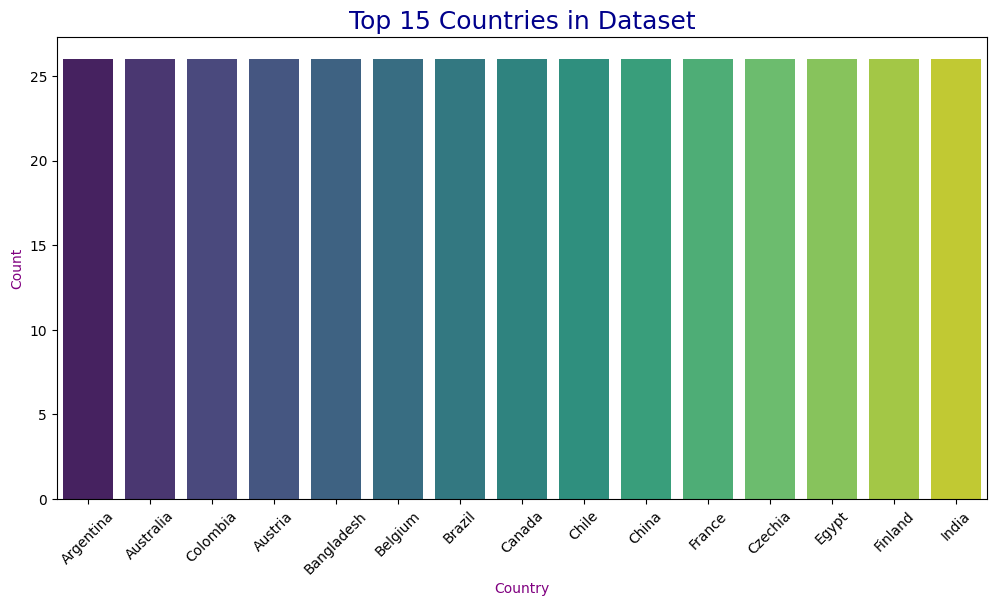

In [14]:
plt.figure(figsize=(12,6))

country_counts = df['country'].value_counts().head(15)

sns.barplot(
    x=country_counts.index,
    y=country_counts.values,
    palette='viridis'
)

plt.title("Top 15 Countries in Dataset", color='darkblue', fontsize=18)
plt.xlabel("Country", color='purple')
plt.ylabel("Count", color='purple')
plt.xticks(rotation=45)

plt.show()

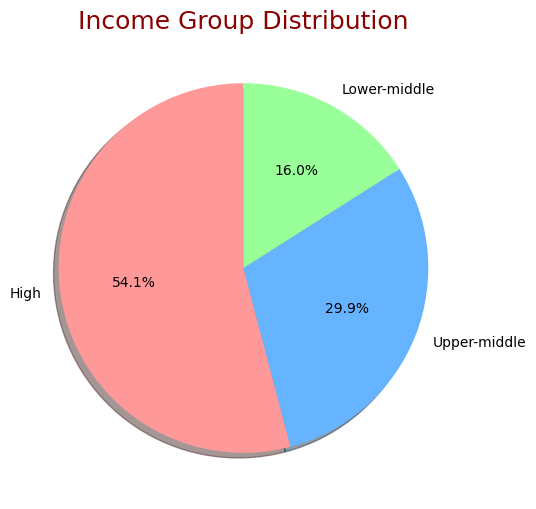

In [15]:
plt.figure(figsize=(10,6))

income_counts = df['income_group'].value_counts()

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

plt.pie(
    income_counts.values,
    labels=income_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    shadow=True
)

plt.title("Income Group Distribution", fontsize=18, color='darkred')

plt.show()

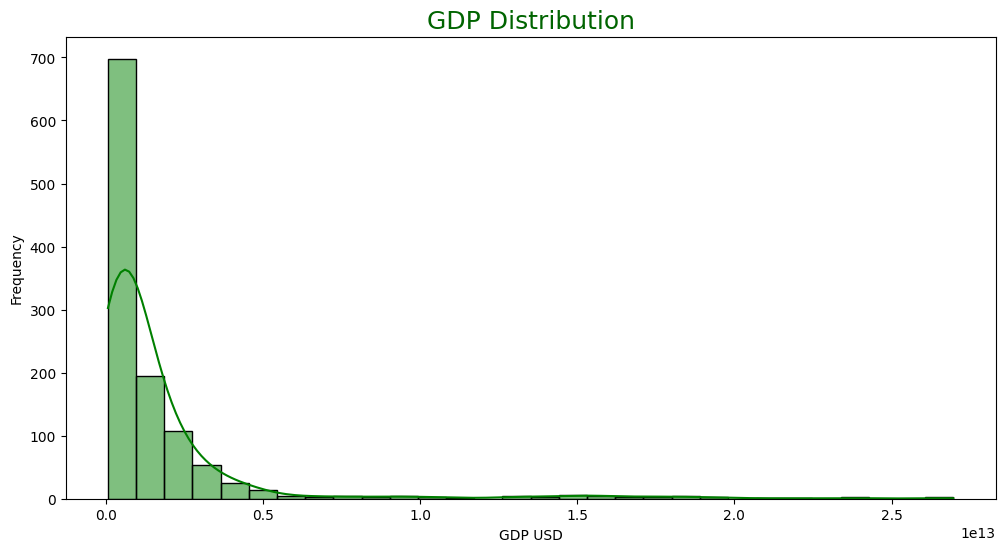

In [16]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['gdp_usd'],
    bins=30,
    kde=True,
    color='green'
)

plt.title("GDP Distribution", fontsize=18, color='darkgreen')
plt.xlabel("GDP USD")
plt.ylabel("Frequency")

plt.show()


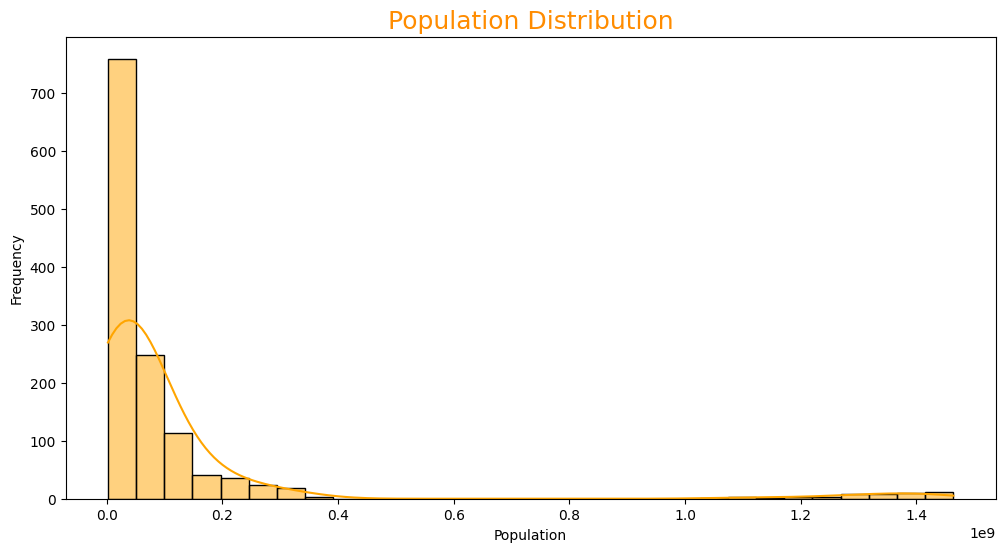

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['population'],
    bins=30,
    kde=True,
    color='orange'
)

plt.title("Population Distribution", fontsize=18, color='darkorange')
plt.xlabel("Population")
plt.ylabel("Frequency")

plt.show()

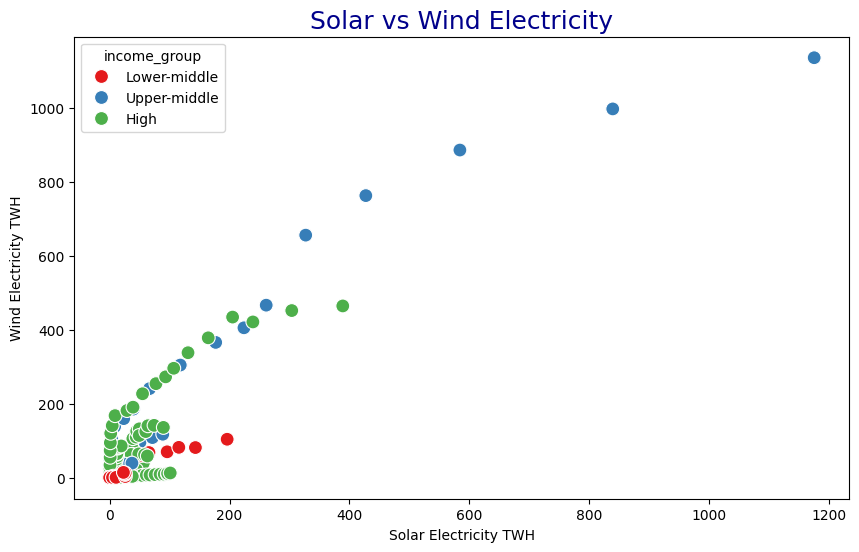

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['solar_electricity_twh'],
    y=df['wind_electricity_twh'],
    hue=df['income_group'],
    palette='Set1',
    s=100
)

plt.title("Solar vs Wind Electricity", fontsize=18, color='darkblue')
plt.xlabel("Solar Electricity TWH")
plt.ylabel("Wind Electricity TWH")

plt.show()


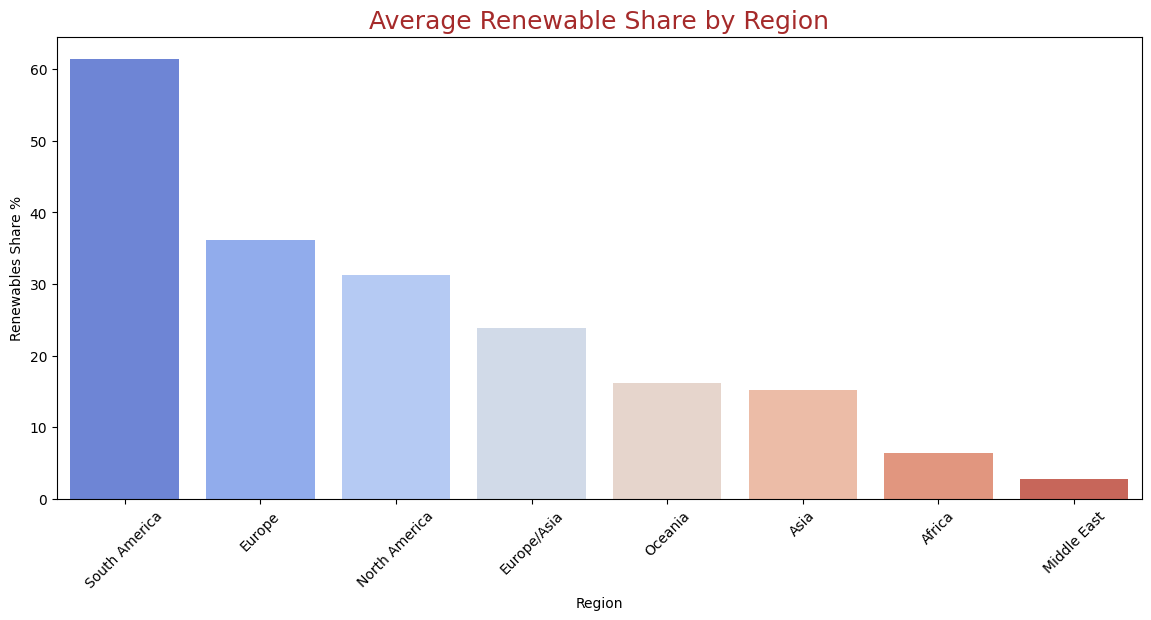

In [19]:
plt.figure(figsize=(14,6))

region_avg = df.groupby('region')['renewables_share_pct'].mean().sort_values(ascending=False)

sns.barplot(
    x=region_avg.index,
    y=region_avg.values,
    palette='coolwarm'
)

plt.title("Average Renewable Share by Region", fontsize=18, color='brown')
plt.xlabel("Region")
plt.ylabel("Renewables Share %")
plt.xticks(rotation=45)

plt.show()

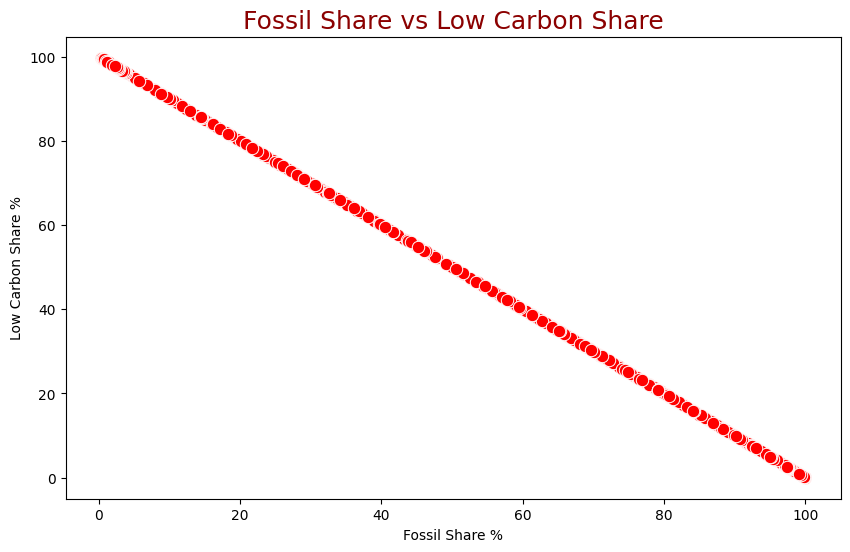

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['fossil_share_pct'],
    y=df['low_carbon_share_pct'],
    color='red',
    s=80
)

plt.title("Fossil Share vs Low Carbon Share", fontsize=18, color='darkred')
plt.xlabel("Fossil Share %")
plt.ylabel("Low Carbon Share %")

plt.show()

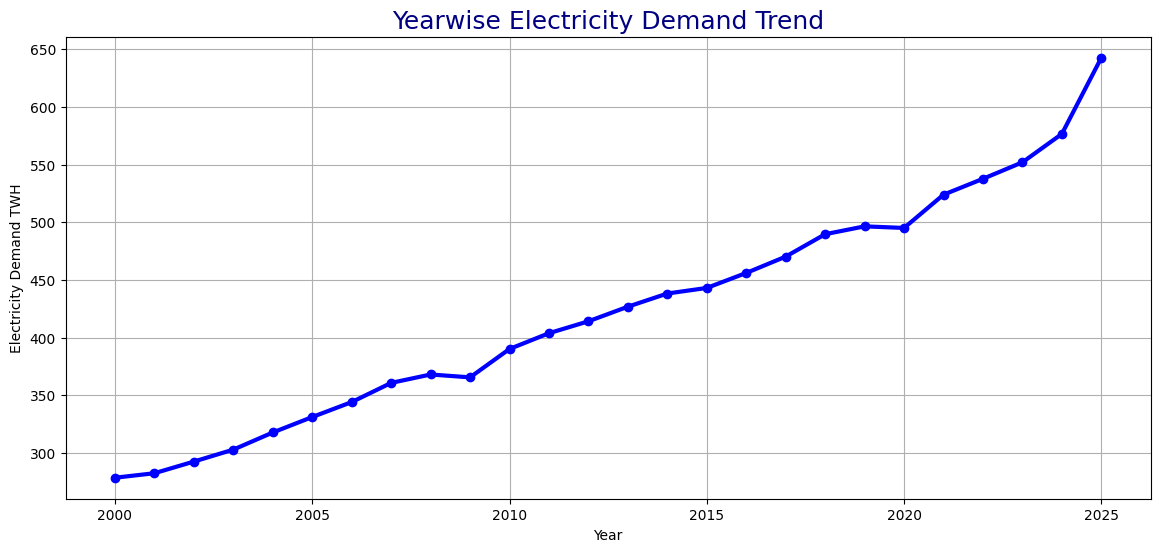

In [21]:
plt.figure(figsize=(14,6))

year_demand = df.groupby('year')['electricity_demand_twh'].mean()

plt.plot(
    year_demand.index,
    year_demand.values,
    marker='o',
    linewidth=3,
    color='blue'
)

plt.title("Yearwise Electricity Demand Trend", fontsize=18, color='navy')
plt.xlabel("Year")
plt.ylabel("Electricity Demand TWH")

plt.grid(True)

plt.show()

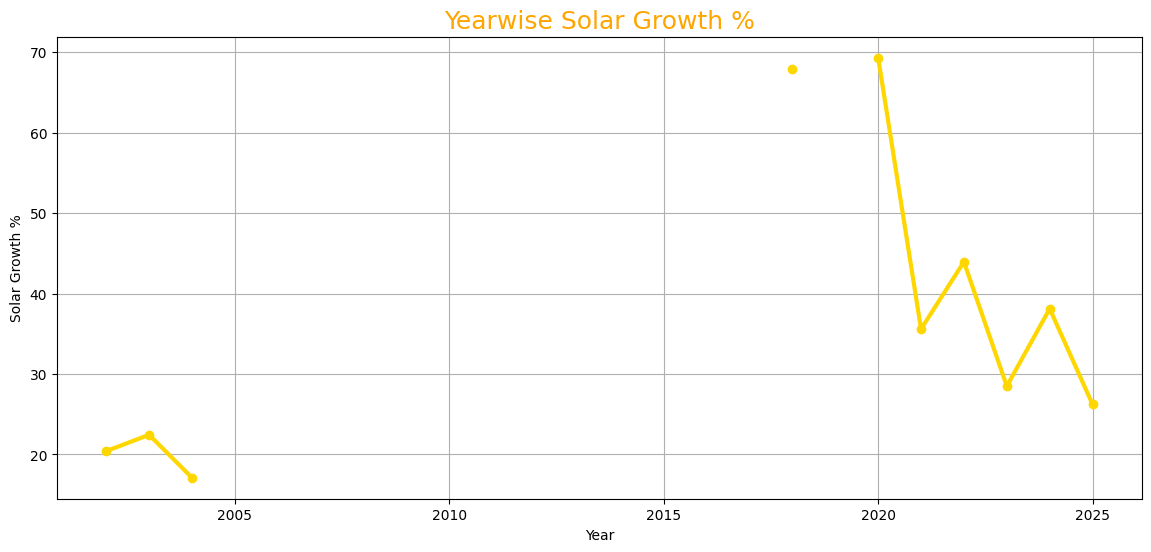

In [22]:
plt.figure(figsize=(14,6))

solar_growth = df.groupby('year')['solar_yoy_growth_pct'].mean()

plt.plot(
    solar_growth.index,
    solar_growth.values,
    marker='o',
    linewidth=3,
    color='gold'
)

plt.title("Yearwise Solar Growth %", fontsize=18, color='orange')
plt.xlabel("Year")
plt.ylabel("Solar Growth %")

plt.grid(True)

plt.show()


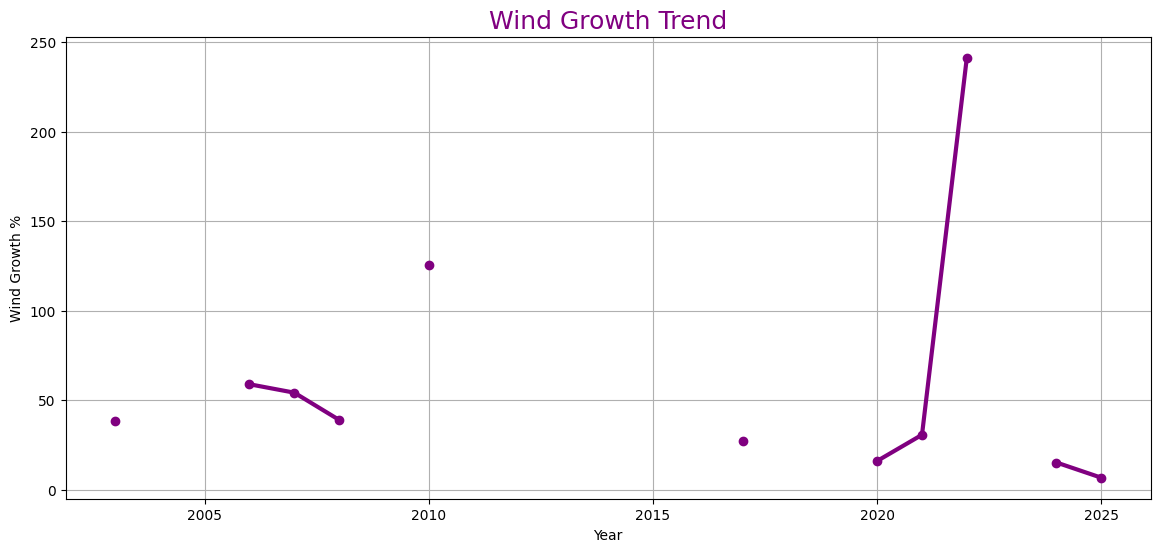

In [23]:
plt.figure(figsize=(14,6))

wind_growth = df.groupby('year')['wind_yoy_growth_pct'].mean()

plt.plot(
    wind_growth.index,
    wind_growth.values,
    marker='o',
    linewidth=3,
    color='purple'
)

plt.title("Wind Growth Trend", fontsize=18, color='purple')
plt.xlabel("Year")
plt.ylabel("Wind Growth %")

plt.grid(True)

plt.show()

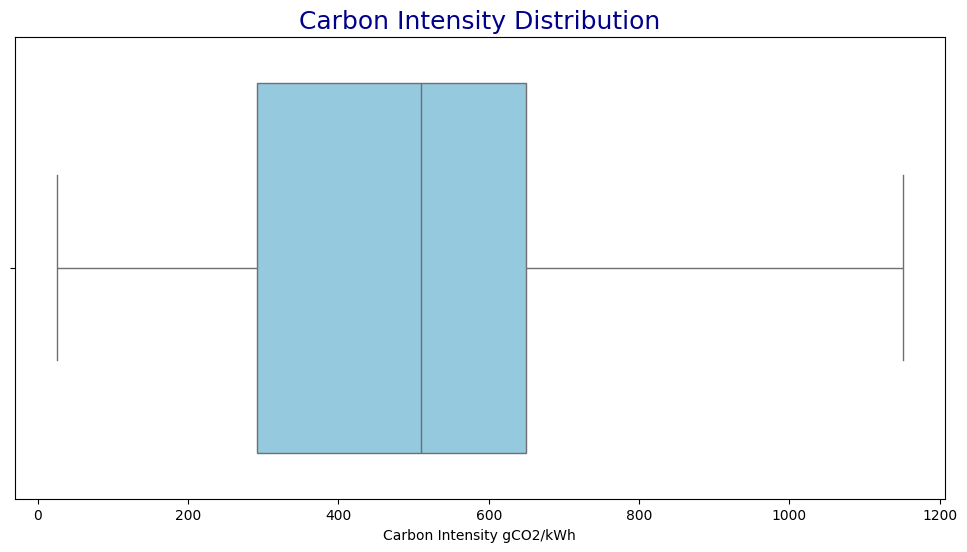

In [24]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=df['carbon_intensity_gco2_kwh'],
    color='skyblue'
)

plt.title("Carbon Intensity Distribution", fontsize=18, color='darkblue')
plt.xlabel("Carbon Intensity gCO2/kWh")

plt.show()

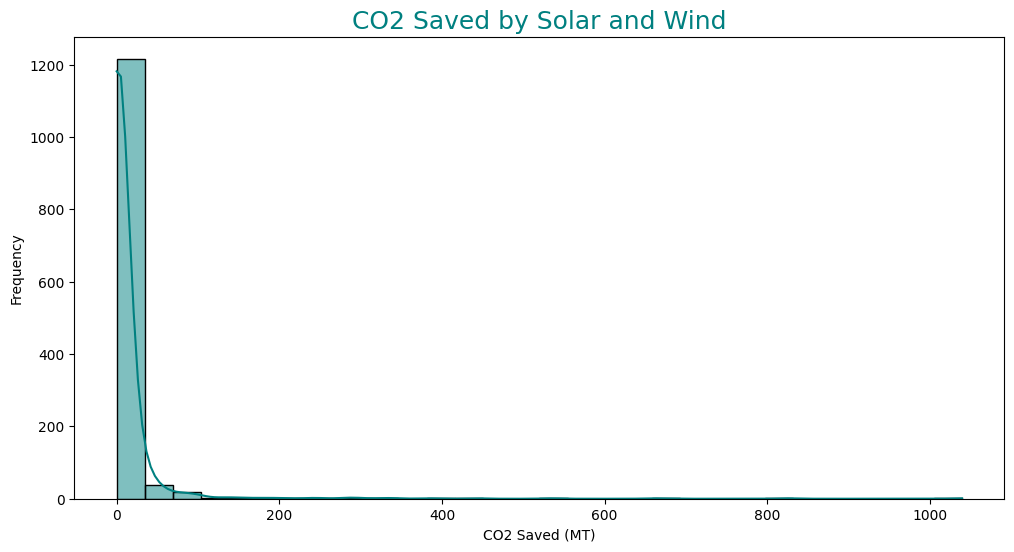

In [25]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['co2_saved_solar_wind_mt'],
    bins=30,
    kde=True,
    color='teal'
)

plt.title("CO2 Saved by Solar and Wind", fontsize=18, color='teal')
plt.xlabel("CO2 Saved (MT)")
plt.ylabel("Frequency")

plt.show()

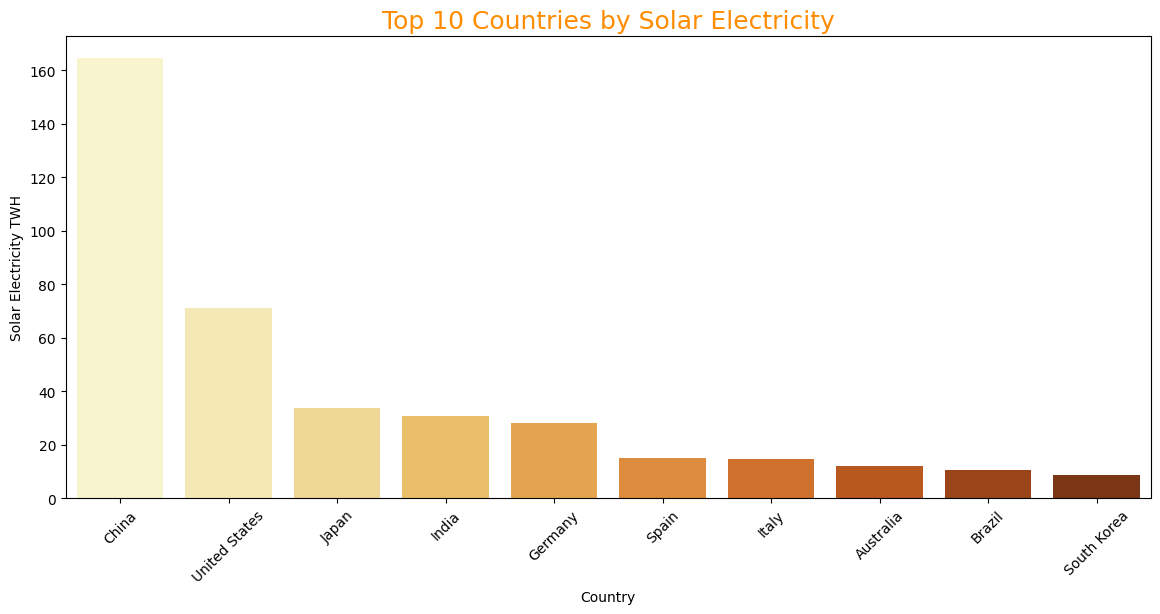

In [26]:
top_solar = (
    df.groupby('country')['solar_electricity_twh']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_solar.index,
    y=top_solar.values,
    palette='YlOrBr'
)

plt.title("Top 10 Countries by Solar Electricity", fontsize=18, color='darkorange')
plt.xlabel("Country")
plt.ylabel("Solar Electricity TWH")
plt.xticks(rotation=45)

plt.show()

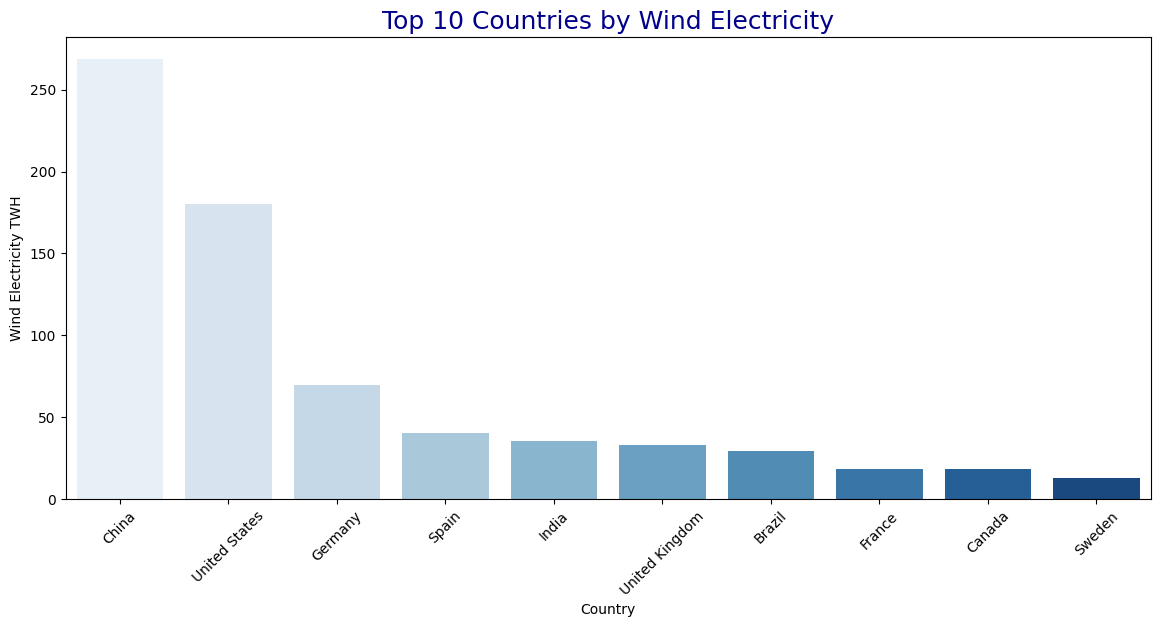

In [27]:
top_wind = (
    df.groupby('country')['wind_electricity_twh']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_wind.index,
    y=top_wind.values,
    palette='Blues'
)

plt.title("Top 10 Countries by Wind Electricity", fontsize=18, color='darkblue')
plt.xlabel("Country")
plt.ylabel("Wind Electricity TWH")
plt.xticks(rotation=45)

plt.show()

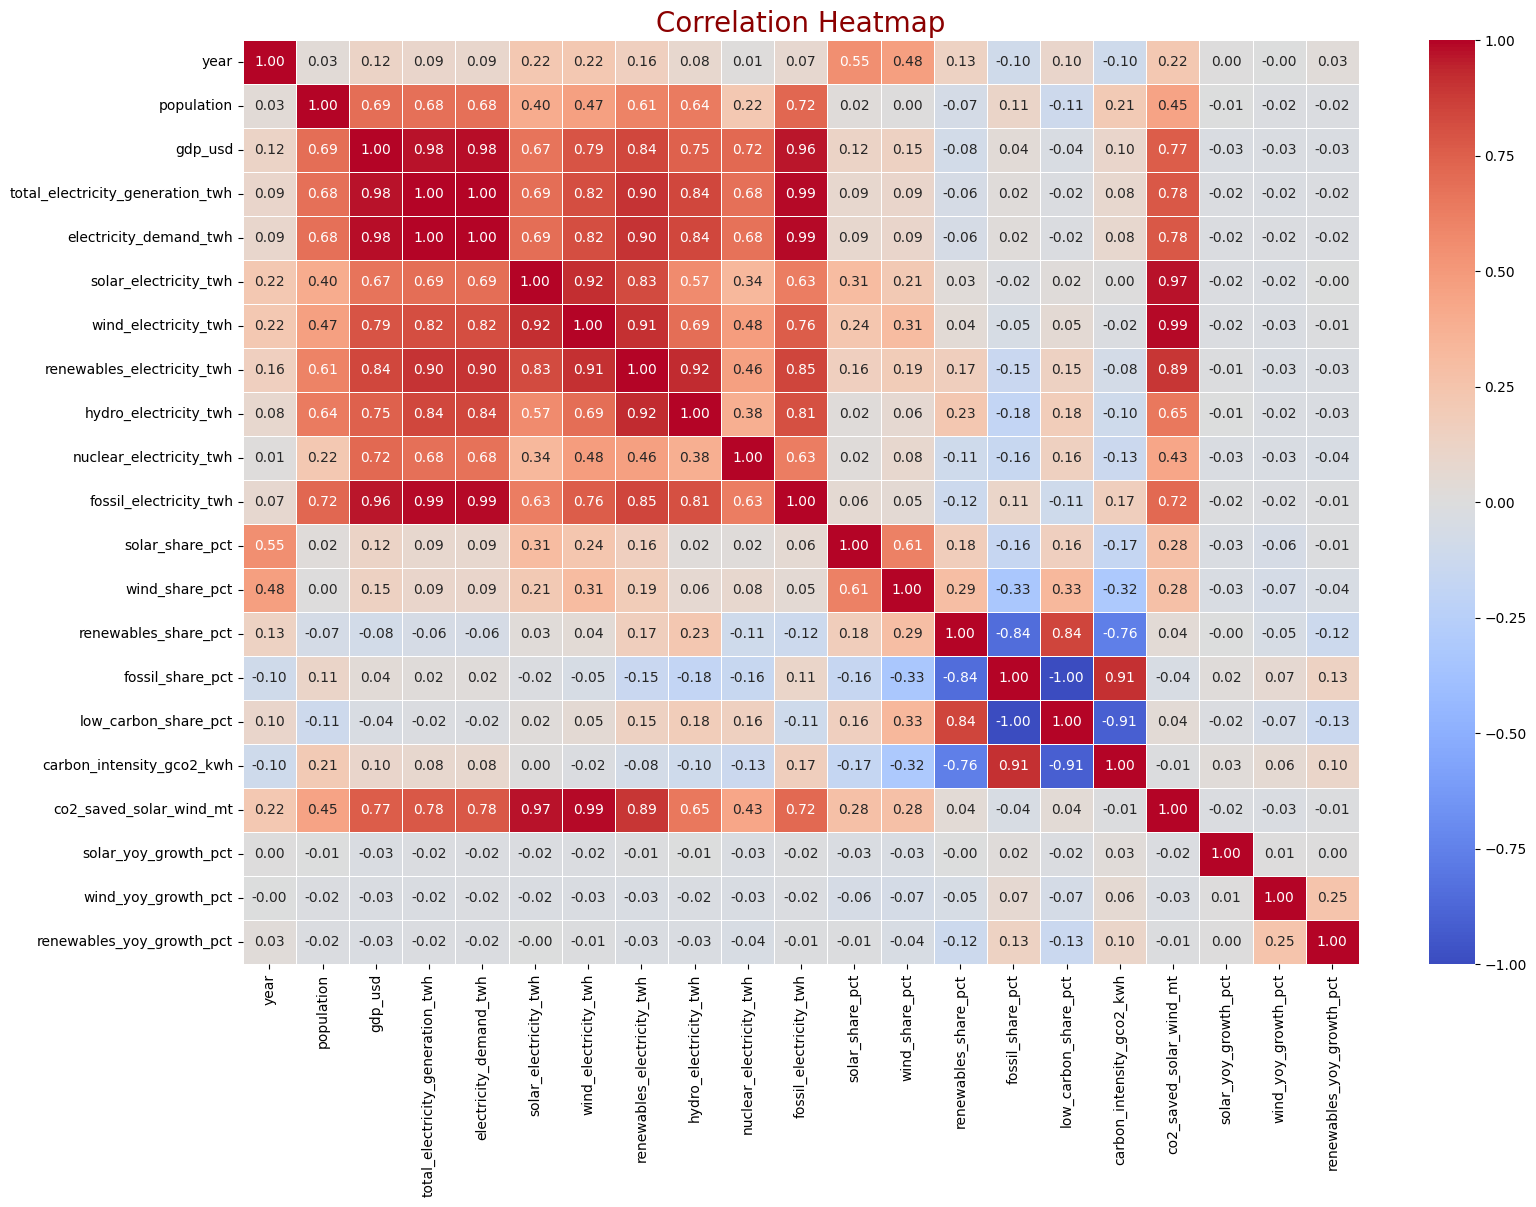

In [28]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(18,12))

corr = numeric_cols.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=20, color='darkred')

plt.show()


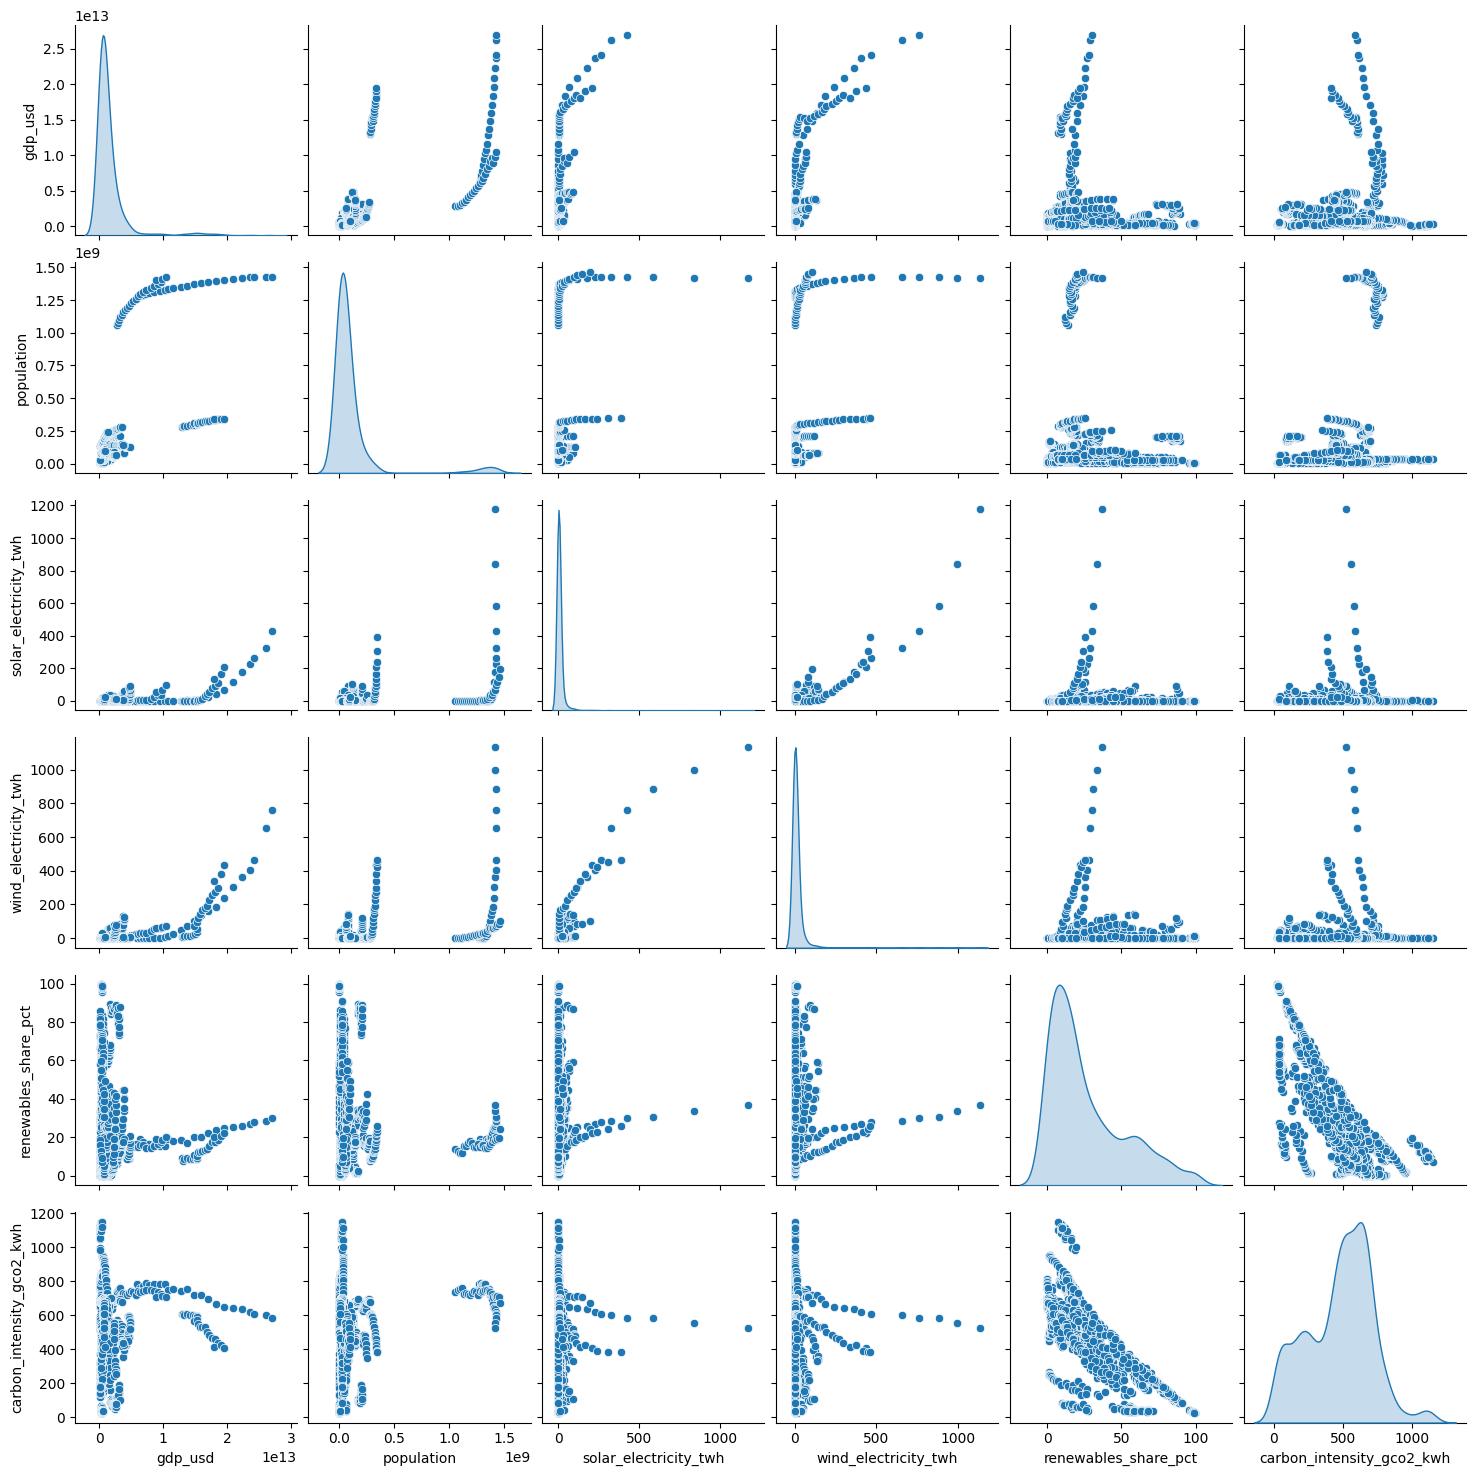

In [29]:
selected_columns = [
    'gdp_usd',
    'population',
    'solar_electricity_twh',
    'wind_electricity_twh',
    'renewables_share_pct',
    'carbon_intensity_gco2_kwh'
]

sns.pairplot(
    df[selected_columns],
    diag_kind='kde'
)

plt.show()

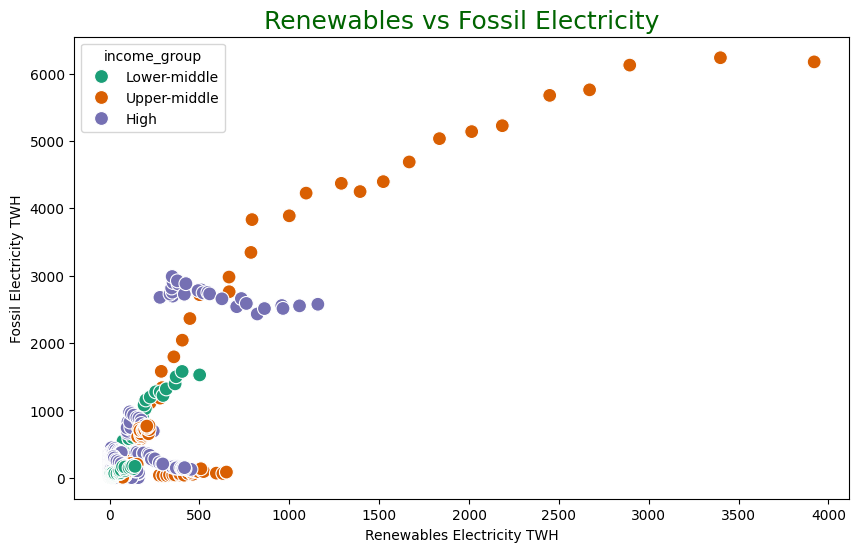

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['renewables_electricity_twh'],
    y=df['fossil_electricity_twh'],
    hue=df['income_group'],
    palette='Dark2',
    s=100
)

plt.title("Renewables vs Fossil Electricity", fontsize=18, color='darkgreen')
plt.xlabel("Renewables Electricity TWH")
plt.ylabel("Fossil Electricity TWH")

plt.show()

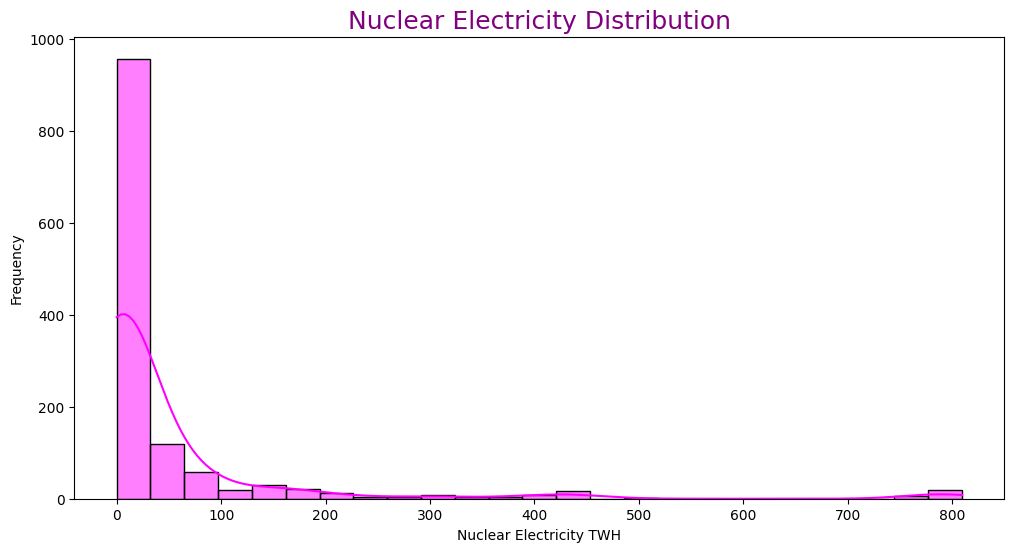

In [31]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['nuclear_electricity_twh'],
    bins=25,
    kde=True,
    color='magenta'
)

plt.title("Nuclear Electricity Distribution", fontsize=18, color='purple')
plt.xlabel("Nuclear Electricity TWH")
plt.ylabel("Frequency")

plt.show()

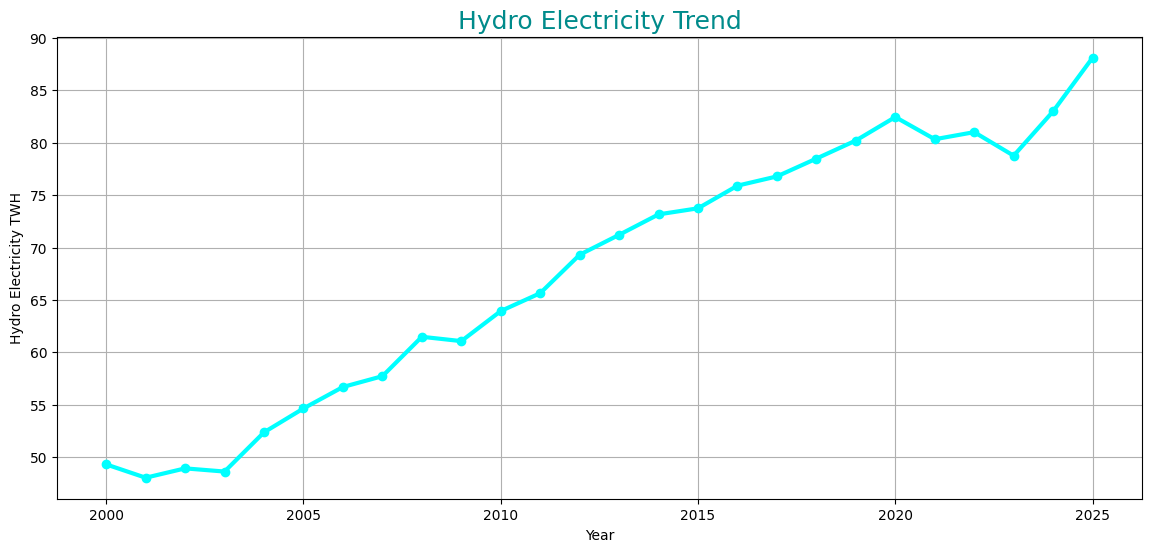

In [32]:
hydro_trend = df.groupby('year')['hydro_electricity_twh'].mean()

plt.figure(figsize=(14,6))

plt.plot(
    hydro_trend.index,
    hydro_trend.values,
    marker='o',
    linewidth=3,
    color='cyan'
)

plt.title("Hydro Electricity Trend", fontsize=18, color='darkcyan')
plt.xlabel("Year")
plt.ylabel("Hydro Electricity TWH")

plt.grid(True)

plt.show()


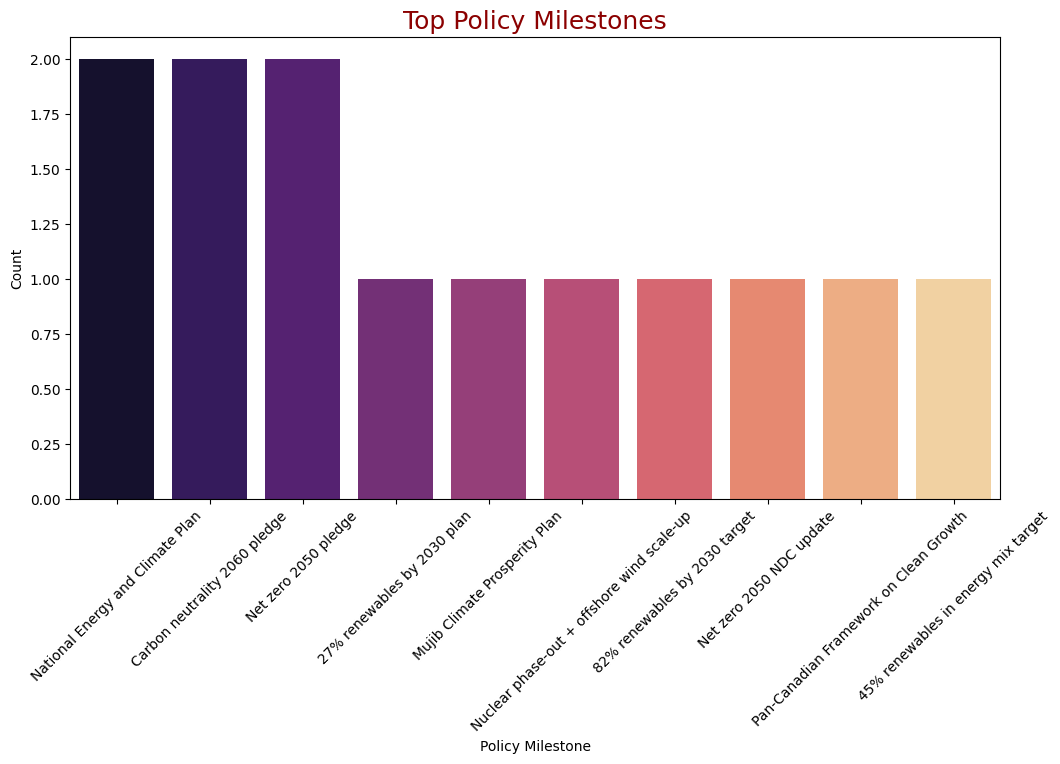

In [33]:
plt.figure(figsize=(12,6))

policy_counts = df['policy_milestone'].value_counts().head(10)

sns.barplot(
    x=policy_counts.index,
    y=policy_counts.values,
    palette='magma'
)

plt.title("Top Policy Milestones", fontsize=18, color='darkred')
plt.xlabel("Policy Milestone")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()


## Feature engineering

In [34]:
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)



Checking Infinity Values...

solar_yoy_growth_pct has 36 infinity values
wind_yoy_growth_pct has 28 infinity values
renewables_yoy_growth_pct has 3 infinity values

Infinity values replaced successfully.
Extreme values cleaned.

Target Distribution:
target
0    647
1    647
Name: count, dtype: int64

Categorical Columns:
['country', 'region', 'income_group', 'policy_milestone']

Numerical Columns:
['year', 'population', 'gdp_usd', 'total_electricity_generation_twh', 'electricity_demand_twh', 'solar_electricity_twh', 'wind_electricity_twh', 'renewables_electricity_twh', 'hydro_electricity_twh', 'nuclear_electricity_twh', 'fossil_electricity_twh', 'solar_share_pct', 'wind_share_pct', 'fossil_share_pct', 'low_carbon_share_pct', 'carbon_intensity_gco2_kwh', 'co2_saved_solar_wind_mt', 'solar_yoy_growth_pct', 'wind_yoy_growth_pct', 'renewables_yoy_growth_pct']

Train Shape: (1035, 24)
Test Shape : (259, 24)


MODEL: Logistic Regression

Accuracy  : 0.9730
Precision : 0.9919
Recall    : 0.95

<Figure size 1200x800 with 0 Axes>

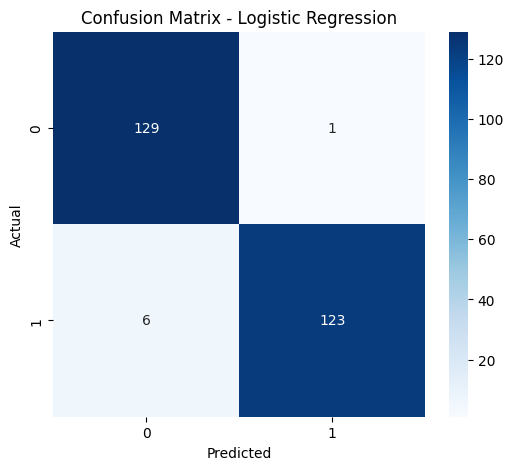



MODEL: Decision Tree

Accuracy  : 0.9459
Precision : 0.9600
Recall    : 0.9302
F1 Score  : 0.9449
ROC AUC   : 0.9781

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       130
           1       0.96      0.93      0.94       129

    accuracy                           0.95       259
   macro avg       0.95      0.95      0.95       259
weighted avg       0.95      0.95      0.95       259



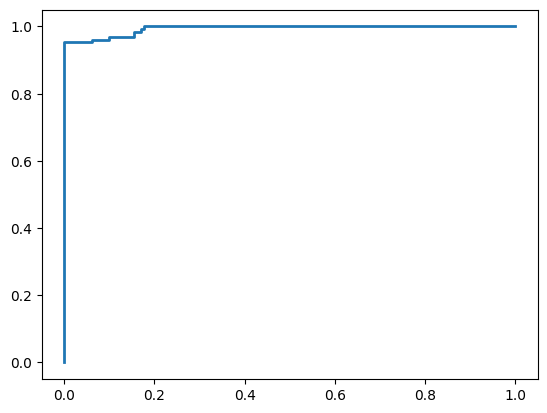

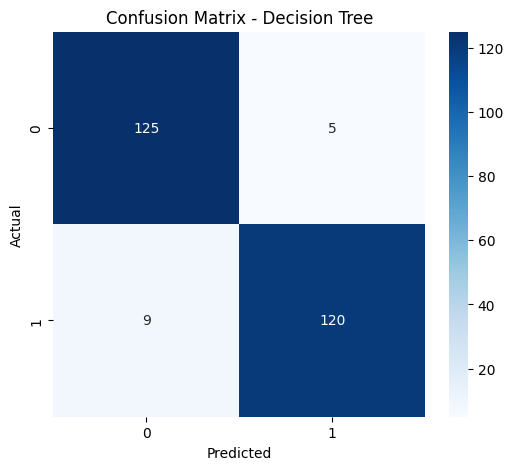



MODEL: Random Forest

Accuracy  : 0.9807
Precision : 0.9921
Recall    : 0.9690
F1 Score  : 0.9804
ROC AUC   : 0.9993

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       130
           1       0.99      0.97      0.98       129

    accuracy                           0.98       259
   macro avg       0.98      0.98      0.98       259
weighted avg       0.98      0.98      0.98       259



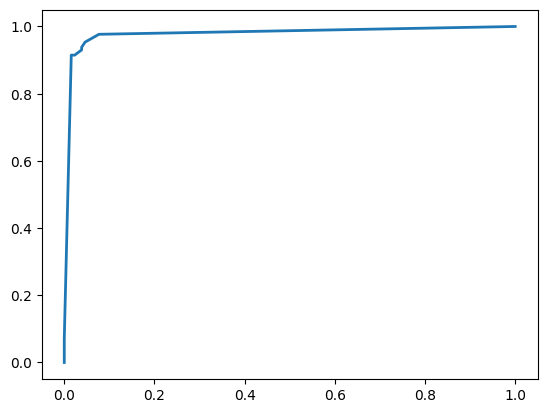

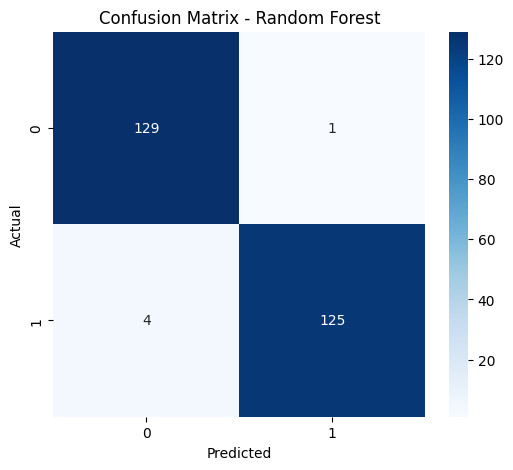



MODEL: Gradient Boosting

Accuracy  : 0.9768
Precision : 0.9920
Recall    : 0.9612
F1 Score  : 0.9764
ROC AUC   : 0.9991

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       130
           1       0.99      0.96      0.98       129

    accuracy                           0.98       259
   macro avg       0.98      0.98      0.98       259
weighted avg       0.98      0.98      0.98       259



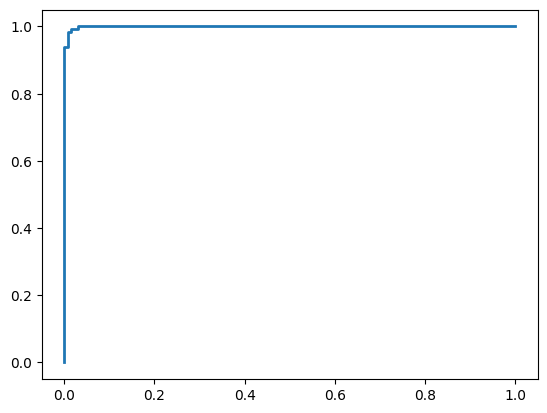

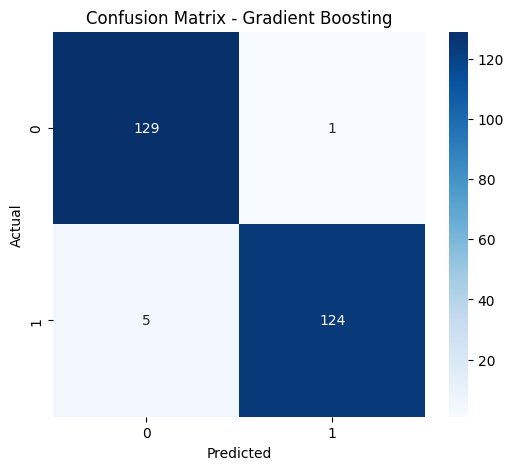



MODEL: KNN

Accuracy  : 0.9459
Precision : 0.9832
Recall    : 0.9070
F1 Score  : 0.9435
ROC AUC   : 0.9888

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.95       130
           1       0.98      0.91      0.94       129

    accuracy                           0.95       259
   macro avg       0.95      0.95      0.95       259
weighted avg       0.95      0.95      0.95       259



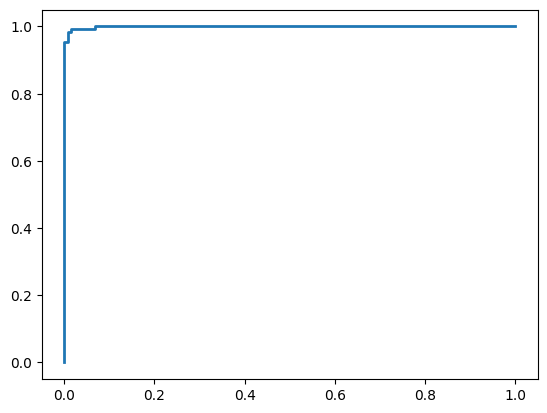

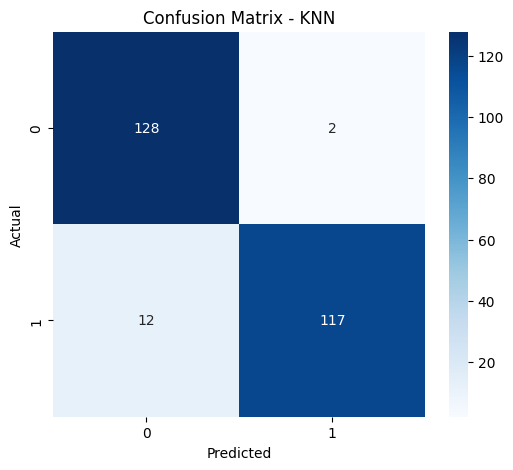

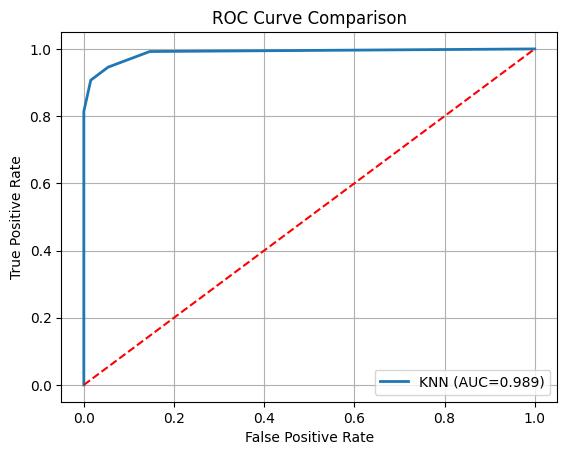



FINAL MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score   ROC_AUC
2        Random Forest  0.980695   0.992063  0.968992  0.980392  0.999284
3    Gradient Boosting  0.976834   0.992000  0.961240  0.976378  0.999106
0  Logistic Regression  0.972973   0.991935  0.953488  0.972332  0.993679
1        Decision Tree  0.945946   0.960000  0.930233  0.944882  0.978056
4                  KNN  0.945946   0.983193  0.906977  0.943548  0.988849


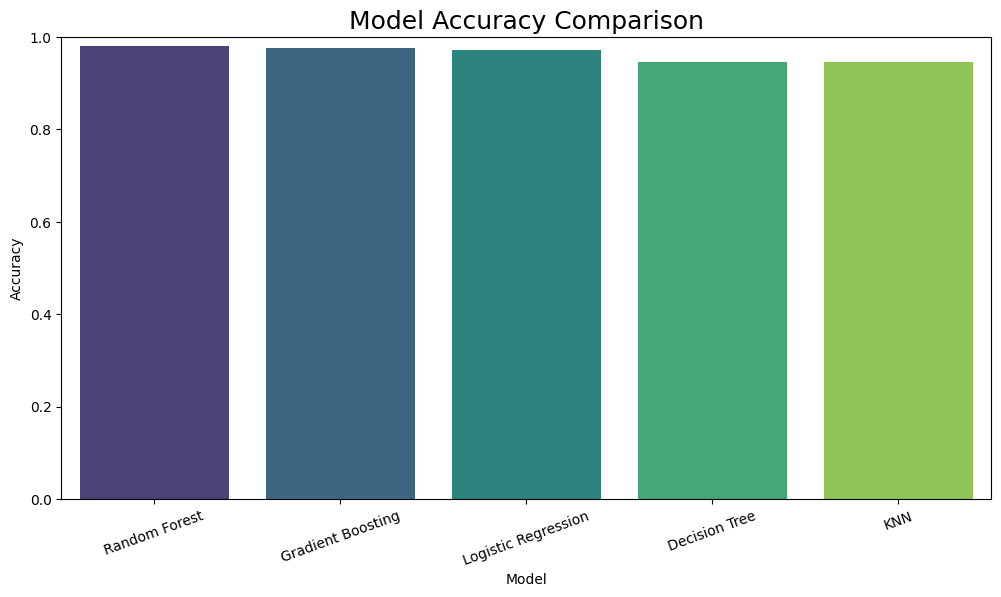

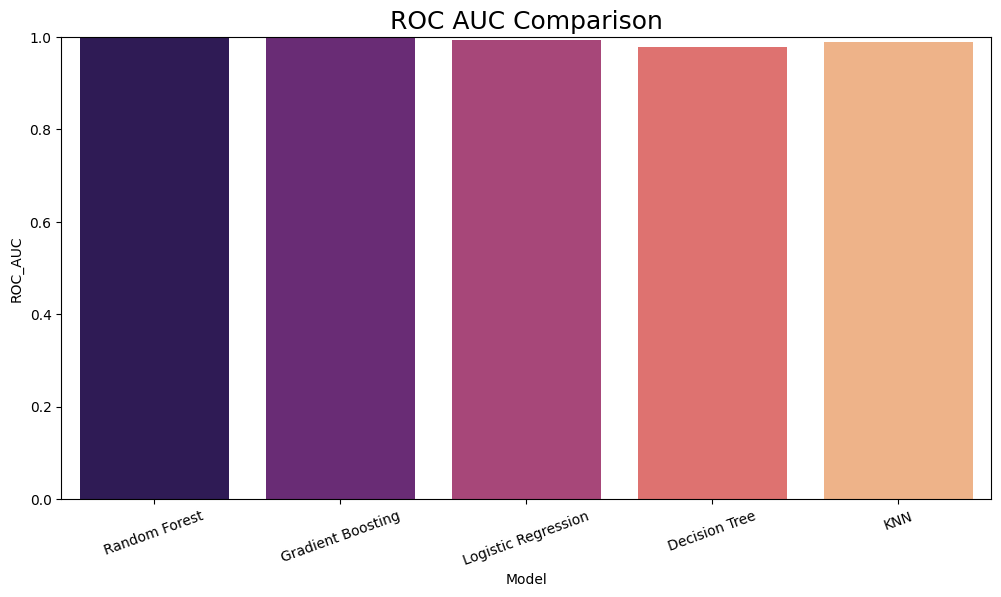



BEST MODEL
Best Model     : Random Forest
Best Accuracy  : 0.9807
Best ROC AUC   : 0.9993

Generating Feature Importance...



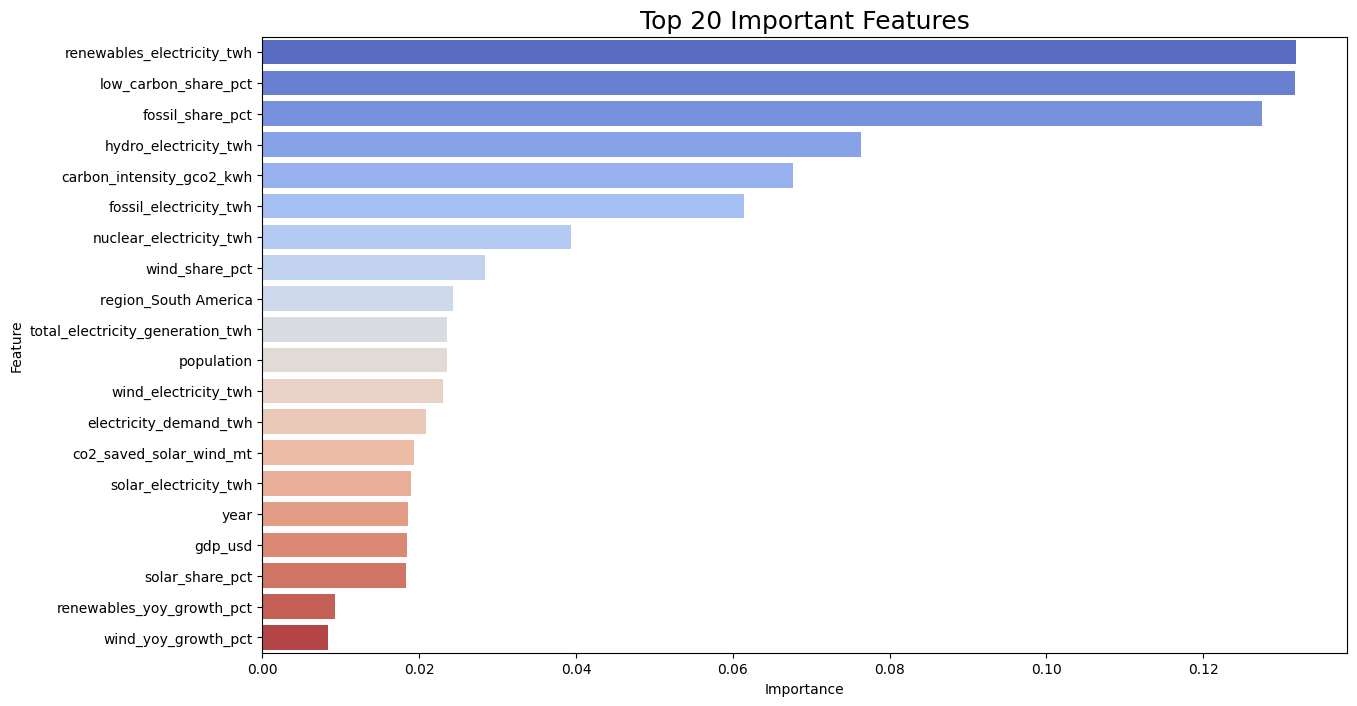

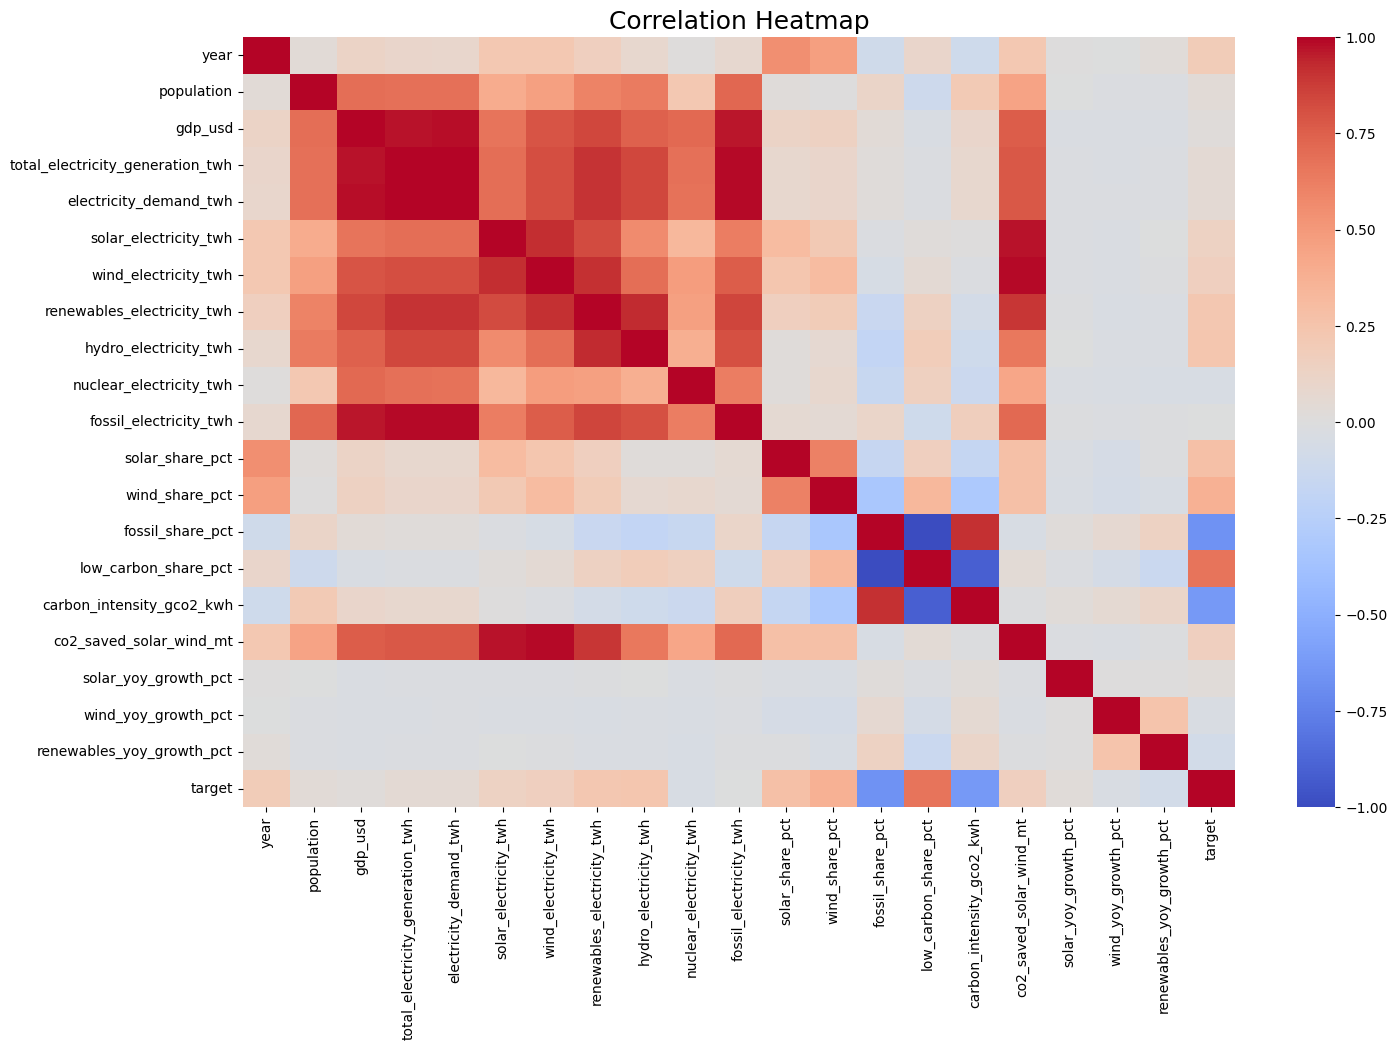



MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY


In [35]:
# ============================================================
# HANDLE INFINITY VALUES
# ============================================================

print("\nChecking Infinity Values...\n")

numeric_cols_check = df.select_dtypes(include=np.number).columns

for col in numeric_cols_check:

    inf_count = np.isinf(df[col]).sum()

    if inf_count > 0:
        print(f"{col} has {inf_count} infinity values")

# Replace infinity with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("\nInfinity values replaced successfully.")

# ============================================================
# HANDLE EXTREME VALUES
# ============================================================

for col in numeric_cols_check:

    df.loc[df[col] > 1e15, col] = np.nan
    df.loc[df[col] < -1e15, col] = np.nan

print("Extreme values cleaned.")

# ============================================================
# CREATE TARGET COLUMN
# ============================================================

# Binary Classification Target
# High renewable share = 1
# Low renewable share = 0

threshold = df['renewables_share_pct'].median()

df['target'] = np.where(
    df['renewables_share_pct'] >= threshold,
    1,
    0
)

print("\nTarget Distribution:")
print(df['target'].value_counts())

# ============================================================
# REMOVE DATA LEAKAGE
# ============================================================

# Remove target-related column
leakage_columns = [
    'renewables_share_pct'
]

df.drop(columns=leakage_columns, inplace=True)

# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop('target', axis=1)

y = df['target']

# ============================================================
# IDENTIFY COLUMNS
# ============================================================

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

# IMPORTANT:
# Split BEFORE preprocessing to avoid leakage

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain Shape:", X_train.shape)

print("Test Shape :", X_test.shape)

# ============================================================
# PREPROCESSING PIPELINES
# ============================================================

# Numerical Pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    )
}

# ============================================================
# STORE RESULTS
# ============================================================

results = []

# ============================================================
# ROC CURVE FIGURE
# ============================================================

plt.figure(figsize=(12,8))

# ============================================================
# TRAIN ALL MODELS
# ============================================================

for model_name, model in models.items():

    print("\n")
    print("="*80)
    print(f"MODEL: {model_name}")
    print("="*80)

    # ========================================================
    # SPECIAL CASE FOR NAIVE BAYES
    # ========================================================

    if model_name == "Naive Bayes":

        # Transform data
        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        # Convert sparse to dense
        X_train_processed = X_train_processed.toarray()
        X_test_processed = X_test_processed.toarray()

        # Train model
        model.fit(X_train_processed, y_train)

        # Predictions
        y_pred = model.predict(X_test_processed)

        # Probabilities
        y_prob = model.predict_proba(X_test_processed)[:,1]

    else:

        # ====================================================
        # PIPELINE
        # ====================================================

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        # ====================================================
        # TRAIN
        # ====================================================

        pipeline.fit(X_train, y_train)

        # ====================================================
        # PREDICT
        # ====================================================

        y_pred = pipeline.predict(X_test)

        # ====================================================
        # PROBABILITY
        # ====================================================

        y_prob = pipeline.predict_proba(X_test)[:,1]

    # ========================================================
    # EVALUATION METRICS
    # ========================================================

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    # ========================================================
    # PRINT SCORES
    # ========================================================

    print(f"\nAccuracy  : {accuracy:.4f}")

    print(f"Precision : {precision:.4f}")

    print(f"Recall    : {recall:.4f}")

    print(f"F1 Score  : {f1:.4f}")

    print(f"ROC AUC   : {roc_auc:.4f}")

    # ========================================================
    # CLASSIFICATION REPORT
    # ========================================================

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # ========================================================
    # CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {model_name}")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # ========================================================
    # ROC CURVE
    # ========================================================

    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC={roc_auc:.3f})"
    )

    # ========================================================
    # STORE RESULTS
    # ========================================================

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC_AUC': roc_auc
    })

# ============================================================
# FINAL ROC CURVE
# ============================================================

plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# RESULTS DATAFRAME
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df)

# ============================================================
# ACCURACY VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df,
    palette='viridis'
)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# ============================================================
# ROC AUC VISUALIZATION
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Model',
    y='ROC_AUC',
    data=results_df,
    palette='magma'
)

plt.title("ROC AUC Comparison", fontsize=18)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# ============================================================
# BEST MODEL
# ============================================================

best_model = results_df.iloc[0]

print("\n")
print("="*60)
print("BEST MODEL")
print("="*60)

print(f"Best Model     : {best_model['Model']}")

print(f"Best Accuracy  : {best_model['Accuracy']:.4f}")

print(f"Best ROC AUC   : {best_model['ROC_AUC']:.4f}")

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

print("\nGenerating Feature Importance...\n")

# Train Random Forest Again
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

# ============================================================
# GET FEATURE NAMES
# ============================================================

encoded_cat_features = rf_pipeline.named_steps[
    'preprocessor'
].named_transformers_[
    'cat'
].named_steps[
    'encoder'
].get_feature_names_out(categorical_cols)

all_features = numerical_cols + list(encoded_cat_features)

# ============================================================
# FEATURE IMPORTANCE VALUES
# ============================================================

importance = rf_pipeline.named_steps[
    'model'
].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(20)

# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(14,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='coolwarm'
)

plt.title("Top 20 Important Features", fontsize=18)

plt.show()

# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(16,10))

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap", fontsize=18)

plt.show()

# ============================================================
# END
# ============================================================

print("\n")
print("="*70)
print("MACHINE LEARNING PIPELINE COMPLETED SUCCESSFULLY")
print("="*70)

## Thank you....pls upvote!!!!!!!!!!!!!!!